# POC 03 — focused AER study: one client, one sensor set, no federation

**Question: can the upstream AER reconstruct a client's windows at all, and what does it
take?** POC_02 decoded flat windows everywhere, but every FL cell there trained 35 Adam
steps per client. The pre-refactor pipeline (2 h aggregation, exactly 7-day windows,
stride 1) gave near-exact reconstructions with far more steps per round.

This notebook removes everything the FL protocol adds: no FedAvg, no prototypes, one client.
It trains the upstream `AER` with the upstream `aer_loss` using plain Adam
(`fedwater_lab/aer_study.py`). The windows come from the same `data.build_windows` path as
the FL cells.

| stage | axis | fixed |
|---|---|---|
| 1 | **step budget × stride × geometry** | client B, pure+mixed |
| 2 | sensor set (pure / mixed / pure+mixed) × client | geometry chosen in 1 |
| 3 | capacity and learning rate | client, sensors and geometry chosen in 1–2 |
| 4 | inspection of one configuration | — |

Every configuration is cached under `lab_sandbox/aer_study/`, so re-running reads from disk.

## 0. Setup

In [1]:
import sys, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"
for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from fedwater_lab.worlds import load_world, pick_world
from fedwater_lab.specs import Geometry
from fedwater_lab import data as D, recon as RC, winrec as WR
from fedwater_lab import aer_study as AS

EXPERIMENTS = REPO / "data" / "09_experiments"
ROOT = LAB_DIR / "lab_sandbox" / "aer_study"
pd.set_option("display.width", 220, "display.max_columns", 40)

## 1. World and each client's sensors

The same world as POC_02. The table lists what each sensor set contains per client. District
D's two `mixed` slots are core sensors (purity 1), so for D `mixed` is effectively a second
pure set.

In [2]:
world = load_world(pick_world(EXPERIMENTS, sim_hash="ece8f4ad92e5", placement_source="dynamic"))
print(world.summary()[["tag", "n_months", "init_months", "final_months"]].to_string())
sp = world.sensor_placement
sp = sp[sp["kind"] == "flow"]
display(sp[["district", "slot", "slot_class", "sensor", "tier", "purity", "second", "w_second"]]
          .round(3))

tag             District_A__LR_LR_LR_LR__baseline
n_months                                       65
init_months                                 0..11
final_months                               64..64


,district,slot,slot_class,sensor,tier,purity,second,w_second
0,District_A,q_pure_0,pure,q_P-42,core,1.000,NaN,0.000
1,District_A,q_pure_1,pure,q_P-556,core,1.000,NaN,0.000
2,District_A,q_mixed_0,mixed,q_P-558,foreign,0.000,District_B,0.725
3,District_A,q_mixed_1,mixed,q_P-10,transition,0.272,District_D,0.728
8,District_B,q_pure_0,pure,q_P-30,core,1.000,NaN,0.000
9,District_B,q_pure_1,pure,q_P-285,core,1.000,NaN,0.000
10,District_B,q_mixed_0,mixed,q_P-605,foreign,0.000,District_A,0.656
11,District_B,q_mixed_1,mixed,q_P-588,transition,0.477,District_C,0.263
16,District_C,q_pure_0,pure,q_P-475,core,1.000,NaN,0.000
17,District_C,q_pure_1,pure,q_P-499,core,1.000,NaN,0.000


## 2. Design

**Split (purged, by month).** Every $k$-th month is held out ($m \bmod k = k-1$, with
$k=5$).
* **Validation** windows are those whose month label is held out.
* **Training** windows are those that touch no held-out month at all.
* Windows in between are dropped.

With stride 1, neighbouring windows are near-copies, so a random split would measure memory,
not reconstruction.

**Scores on validation.** $\mathcal{L}$ is `aer_loss` (same weighting as training), and
$\hat x_w$ is the reconstruction of window $x_w$.

* `ratio` $=\mathcal{L}_{val} / \mathcal{L}(\bar x_w)$, where $\bar x_w$ is each window's own
  input mean at every step, i.e. the best flat line. Below 1, some shape is reconstructed.
* `val_amp` $=\mathrm{median}_{w,i}\ \sigma_t(\hat x_{wi}) / \sigma_t(x_{wi})$: 0 is flat.
* `val_r` $=\mathrm{median}_{w,i}\ \mathrm{corr}_t(\hat x_{wi}, x_{wi})$.
* `base_const` is the loss of the per-channel training mean, a flat line that uses no latent
  at all.

**Comparable budgets.** Strides differ by an order of magnitude in windows per epoch, so each
configuration gets the same number of **optimiser steps** (`AS.budget`). The curves are
plotted against steps, and the weights with the best validation loss are kept.

## 3. Stage 1 — step budget, stride, geometry

| config | window | stride | note |
|---|---|---|---|
| `a3w84s12` | 10.5 d | 36 h | the POC geometry |
| `a3w84s4` | 10.5 d | 12 h | |
| `a3w84s1` | 10.5 d | 3 h | |
| `a2w84s1` | 7 d | 2 h | **legacy** pipeline geometry |
| `a3w56s1` | 7 d | 3 h | whole week at the POC aggregation |

`STEPS` optimiser steps each. Early stopping is off here, so the full curve is visible;
`patience = 0`. On a GPU this is minutes per configuration. The longest are the stride-1
cells, at roughly 7,000–11,000 windows.

In [ ]:
CLIENT = "District_B"
STEPS = 6000
BASE = AS.StudyCfg(client=CLIENT, slots="pure+mixed", patience=0, lr=1e-3, lstm_units=30)

GEOMS = {
    "a3w84s12": Geometry(3, 84, 12),
    "a3w84s4":  Geometry(3, 84, 4),
    "a3w84s1":  Geometry(3, 84, 1),
    "a2w84s1":  Geometry(2, 84, 1),
    "a3w56s1":  Geometry(3, 56, 1),
}
RUN_STAGE1 = True
if RUN_STAGE1:
    S1_CFG = {k: AS.budget(world, BASE.with_(geometry=g), STEPS, cache=D.CACHE)
              for k, g in GEOMS.items()}
    S1 = AS.run_studies(world, S1_CFG, ROOT, cache=D.CACHE)
    display(AS.summary_table(S1))
    fig, ax = plt.subplots(1, 3, figsize=(17, 4))
    AS.plot_curves(ax, S1)
    fig.tight_layout()
    plt.show()

**Reading stage 1.**
* **Flat everywhere** (`ratio` ≥ 1, `val_amp` ≈ 0 at every budget): the step budget is not
  the cause, so check the data path next, starting with §5's window view.
* **Shape appears after some number of steps** (a knee in the curves): the FL cells simply
  never reached it, and that step count is the budget the FL training needs per client.
* **Only stride 1 or only 7-day windows work**: the geometry matters beyond step count, and
  the POC geometry is the problem.

## 4. Stage 2 — sensor set × client

This uses the geometry chosen from stage 1 and the same step budget. `ratio` and `val_r` are
shown per client × sensor set.

In [4]:
GEOM2 = GEOMS["a3w84s4"]          # set from stage 1
RUN_STAGE2 = True
if RUN_STAGE2:
    S2_CFG = {}
    for c in world.client_names:
        for slots in AS.SLOT_SETS:
            cfg = BASE.with_(client=c, slots=slots, geometry=GEOM2)
            S2_CFG[f"{c.replace('District_', '')}·{slots}"] = AS.budget(world, cfg, STEPS,
                                                                        cache=D.CACHE)
    S2 = AS.run_studies(world, S2_CFG, ROOT, cache=D.CACHE, verbose=False)
    T2 = AS.summary_table(S2)
    T2["client"] = [k.split("·")[0] for k in T2.index]
    T2["slots"] = [k.split("·")[1] for k in T2.index]
    for m in ("ratio", "val_amp", "val_r"):
        display(T2.pivot_table(index="client", columns="slots", values=m,
                               aggfunc="first").astype(float).round(3)
                  .rename_axis(columns=m))

ratio,mixed,pure,pure+mixed
client,,,
A,0.155,0.045,0.083
B,0.206,0.007,0.077
C,0.219,0.009,0.054
D,0.003,0.004,0.005


val_amp,mixed,pure,pure+mixed
client,,,
A,0.837,0.960,0.929
B,0.765,0.997,0.965
C,0.869,0.986,0.977
D,0.998,0.998,0.997


val_r,mixed,pure,pure+mixed
client,,,
A,0.835,0.976,0.935
B,0.780,0.995,0.974
C,0.886,0.993,0.984
D,0.998,0.997,0.997


## 5. Stage 3 — capacity and learning rate (optional)

This runs on one (client, sensor set) at `GEOM2`.

In [5]:
RUN_STAGE3 = False
if RUN_STAGE3:
    S3_CFG = {f"u{u}·lr{lr:g}": AS.budget(world, BASE.with_(geometry=GEOM2, lstm_units=u, lr=lr),
                                          STEPS, cache=D.CACHE)
              for u in (30, 60) for lr in (1e-3, 3e-3)}
    S3 = AS.run_studies(world, S3_CFG, ROOT, cache=D.CACHE)
    display(AS.summary_table(S3))
    fig, ax = plt.subplots(1, 3, figsize=(17, 4))
    AS.plot_curves(ax, S3)
    fig.tight_layout()
    plt.show()

## 6. Inspect one configuration

The best-validation weights are applied to **every** window of the client, and each window
is marked `train` / `val` / `dropped`. The tools are POC_02's:

* **Scores by split and phase.** Validation is the honest column.
* **Position profile**, over validation windows:
  $r_t = \mathrm{corr}_w(\hat x_w[t], x_w[t])$. A decoder that reproduces the first steps and
  then settles to a constant falls to 0 there.
* **Window browser.** One window, plus the overlap-add timeline. The timeline averages many
  windows, so a per-window failure can hide in it; read the profile first.

rmse      r    amp    lvl
split   phase      slot_class                            
dropped init       mixed       0.128  0.976  0.984  0.001
                   pure        0.094  0.987  0.968 -0.007
        transition mixed       0.253  0.846  0.847 -0.004
                   pure        0.095  0.987  0.982 -0.003
train   init       mixed       0.131  0.976  0.982  0.001
                   pure        0.104  0.984  0.974 -0.000
        transition mixed       0.260  0.840  0.841 -0.003
                   pure        0.101  0.985  0.980 -0.001
val     final      mixed       0.264  0.828  0.866  0.017
                   pure        0.094  0.987  0.995  0.003
        init       mixed       0.139  0.973  0.975  0.000
                   pure        0.101  0.985  0.963 -0.003
        transition mixed       0.255  0.848  0.836 -0.005
                   pure        0.098  0.986  0.986 -0.004

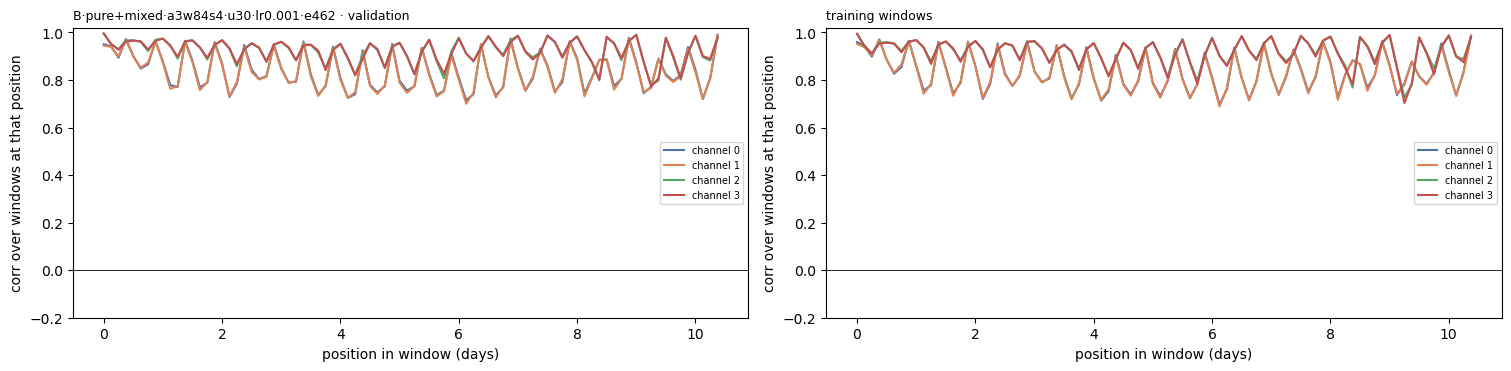

In [6]:
PICK = S1["a3w84s4"] if RUN_STAGE1 else None      # any output of run_study
run, fw1, split = AS.view(world, PICK)
chan1 = RC.channel_table(world, fw1)
WS1 = WR.window_scores(run, fw1, chan1).merge(split, on="row")
display(WS1.groupby(["split", "phase", "slot_class"])[["rmse", "r", "amp", "lvl"]]
           .median().round(3))

c1 = PICK["cfg"].client
fig, ax = plt.subplots(1, 2, figsize=(15, 3.6), layout="constrained")
WR.plot_step_profile(ax[0], WR.step_profile(run, fw1, c1, split.loc[split.split == "val", "row"]),
                     run.agg_h, title=f"{PICK['summary']['label']} · validation")
WR.plot_step_profile(ax[1], WR.step_profile(run, fw1, c1, split.loc[split.split == "train", "row"]),
                     run.agg_h, title="training windows")
plt.show()

In [ ]:
_ = WR.window_browser(run, fw1, WS1, chan1)

## 7. What this feeds back into POC_02

* **The step budget.** `best_steps` at the knee is the per-client budget an FL cell needs:
  rounds × local epochs × batches. With stride 12 there are 7 batches per epoch, so a knee at
  a few thousand steps means hundreds of local epochs. That favours the smaller stride found
  here rather than more rounds.
* **The geometry.** If a whole-week window (`a2w84` / `a3w56`) is clearly better, the
  weekday × hour key of POC_02 §6 simplifies too, since every start then shares the week
  phase up to the stride.
* **The sensor set.** If `mixed` alone reconstructs worse than `pure`, the mixture signal is
  harder for the model, which matters for the dependence question.
* **If nothing reconstructs at any budget,** the AER itself is the next target: a decoder
  that receives a per-step time encoding alongside $z$. That is an upstream change.